# Importare librarii
Pentru inceput, vom importa toate librariile necesare

In [ ]:
#librarii principale
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from IPython.display import display

#procesare si selectia variabilelor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif

#selectarea modelului si evaluarea
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

#modele de invatare
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Incarcarea setului de date si identificarea atributului tinta


## Incarcarea setului de date
Pentru inceput, vom incarca setul de date si vom printa primele 5 randuri (table head) pentru a verifica incarcarea corecta a acestuia.

In [ ]:
df = pd.read_csv("sample_data/flight_data.csv", low_memory=False, on_bad_lines='skip') #incarcarea fisierului integral in variabila df (data frame)
df.head() #afisarea primelor randuri pentru verificare

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


## Filtrarea datelor
Deoarece setul ales contine informatii despre toate aeroporturile din Statele Unite ale Americii, atat plecari cat si sosiri, va trebui sa le filtram, astfel incat sa ramanem doar cu datele corecte pentru scopul proiectului nostru: plecarile din Aeroportul San Jose, California.

In [ ]:
df = df[df['Origin'] == 'SJC'] #plecari (Origin) din SJC (San Jose California)

Heatmap cu distributia valorilor lipsa

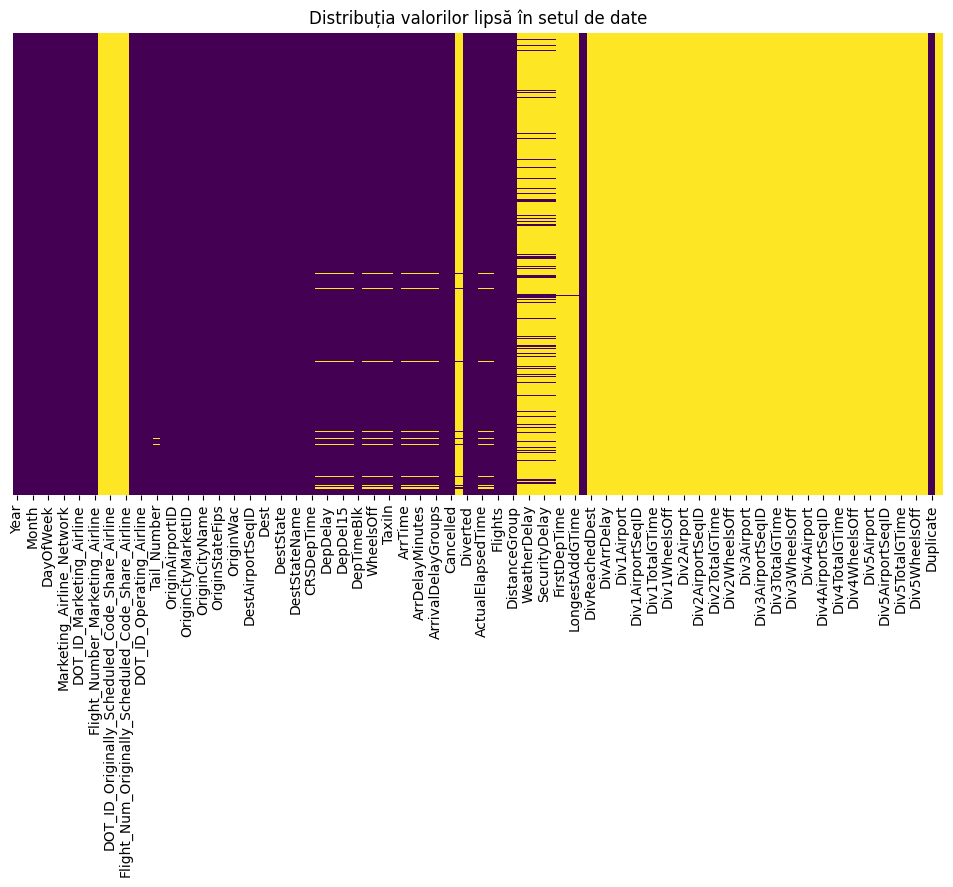

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis') #cbar = colorbar, yticklabels=hides row tables, cmap=color map
plt.title("Distribuția valorilor lipsă în setul de date")
plt.show()

Grafic care ne arata existenta coloanelor cu valoare constanta

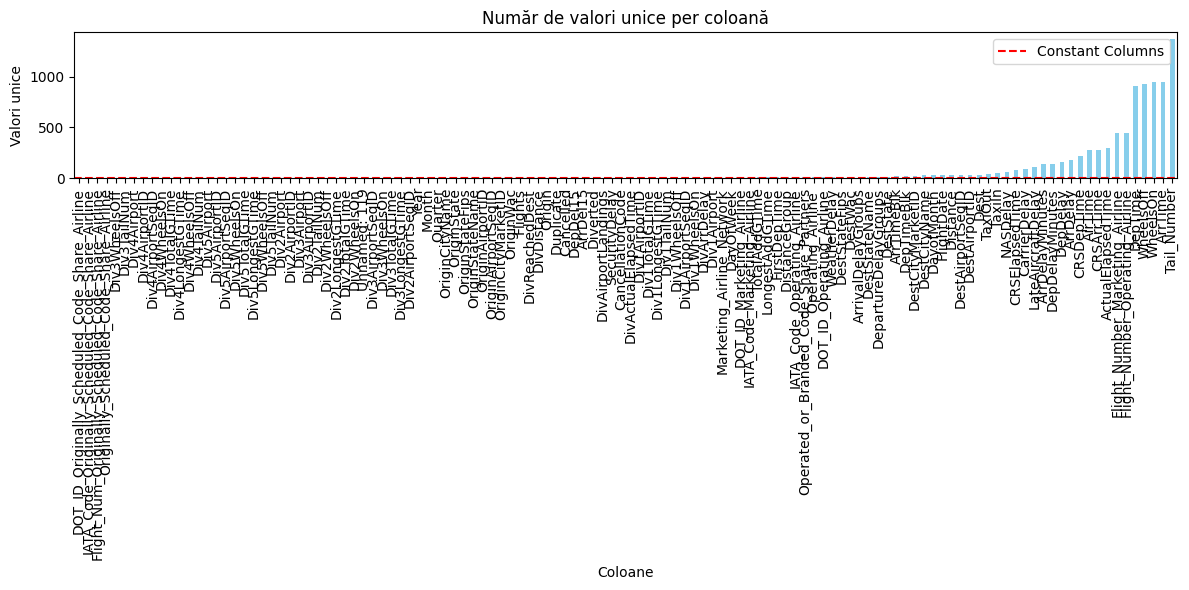

In [ ]:
#calculam numarul de valori unice in fiecare coloana
unique_counts = df.nunique().sort_values()

# plot
plt.figure(figsize=(12, 6))
unique_counts.plot(kind='bar', color='skyblue')
plt.axhline(1, color='red', linestyle='--', label='Constant Columns')
plt.title("Număr de valori unice per coloană")
plt.ylabel("Valori unice")
plt.xlabel("Coloane")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout() #labelurile nu vor avea overlap
plt.show()


In continuare, vom identifica daca exista coloane goale pentru toate instantele si cele care au aceeasi valoare pentru toate instantele.

In [ ]:
#coloane goale
empty_cols = df.columns[df.isnull().all()]
print("Numar coloane goale:", len(empty_cols))
print("Coloane goale:", list(empty_cols))

#coloane constante (cu aceesi valoare pentru toate instantele)
constant_cols = df.columns[df.nunique() == 1]
print("Numar coloane constante:", len(constant_cols))
print("Coloane constante:", list(constant_cols))

Numar coloane goale: 37
Coloane goale: ['Originally_Scheduled_Code_Share_Airline', 'DOT_ID_Originally_Scheduled_Code_Share_Airline', 'IATA_Code_Originally_Scheduled_Code_Share_Airline', 'Flight_Num_Originally_Scheduled_Code_Share_Airline', 'Div2Airport', 'Div2AirportID', 'Div2AirportSeqID', 'Div2WheelsOn', 'Div2TotalGTime', 'Div2LongestGTime', 'Div2WheelsOff', 'Div2TailNum', 'Div3Airport', 'Div3AirportID', 'Div3AirportSeqID', 'Div3WheelsOn', 'Div3TotalGTime', 'Div3LongestGTime', 'Div3WheelsOff', 'Div3TailNum', 'Div4Airport', 'Div4AirportID', 'Div4AirportSeqID', 'Div4WheelsOn', 'Div4TotalGTime', 'Div4LongestGTime', 'Div4WheelsOff', 'Div4TailNum', 'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID', 'Div5WheelsOn', 'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum', 'Unnamed: 119']
Numar coloane constante: 16
Coloane constante: ['Year', 'Quarter', 'Month', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName', 'OriginState', 'OriginSta

Am identificat 37 de coloane goale si 16 coloane cu valori unice, urmand sa dam drop acestor coloane.

In [ ]:
df.drop(columns=empty_cols, inplace=True) #inplace = dam drop fara a crea o copie
df.drop(columns=constant_cols, inplace=True)

Mai departe, vom afisa numarul de instante si de atribute.

In [ ]:
print ("Numar instante si atribute: ", df.shape)

Numar instante si atribute:  (3880, 67)


# Identificarea variabilei tinta


In continuare, vom afisa numele coloanelor pentru a identifica variabila tinta (dependenta). Cautam o variabila, care sa satisfaca urmatoarea regula de clasificare:
- `1` sau `delayed` daca intarzierea este `≥15 min`
- `0` sau `on time` daca intarzierea este `<15 min`

In [ ]:
for col in df.columns:
  print(col)

DayofMonth
DayOfWeek
FlightDate
Marketing_Airline_Network
Operated_or_Branded_Code_Share_Partners
DOT_ID_Marketing_Airline
IATA_Code_Marketing_Airline
Flight_Number_Marketing_Airline
Operating_Airline 
DOT_ID_Operating_Airline
IATA_Code_Operating_Airline
Tail_Number
Flight_Number_Operating_Airline
DestAirportID
DestAirportSeqID
DestCityMarketID
Dest
DestCityName
DestState
DestStateFips
DestStateName
DestWac
CRSDepTime
DepTime
DepDelay
DepDelayMinutes
DepDel15
DepartureDelayGroups
DepTimeBlk
TaxiOut
WheelsOff
WheelsOn
TaxiIn
CRSArrTime
ArrTime
ArrDelay
ArrDelayMinutes
ArrDel15
ArrivalDelayGroups
ArrTimeBlk
Cancelled
CancellationCode
Diverted
CRSElapsedTime
ActualElapsedTime
AirTime
Distance
DistanceGroup
CarrierDelay
WeatherDelay
NASDelay
SecurityDelay
LateAircraftDelay
FirstDepTime
TotalAddGTime
LongestAddGTime
DivAirportLandings
DivActualElapsedTime
DivArrDelay
Div1Airport
Div1AirportID
Div1AirportSeqID
Div1WheelsOn
Div1TotalGTime
Div1LongestGTime
Div1WheelsOff
Div1TailNum


Observam ca exista o coloana numita DepDel15, care pare a fi exact coloana de care avem nevoie. Dorim, insa, sa verificam corectitudinea acestei prezumtii si sa verificam daca aceasta are o valoare pentru toate zborurile.

In [ ]:
#dam drop la valorile nule pentru o verificare corecta
cross_check_drop_nul = df[["DepDelayMinutes", "DepDel15"]].dropna()

#verificam daca sunt zboruri sub 15 minute intarziere care sunt marcate ca si intarziate
cross_check = cross_check_drop_nul[(cross_check_drop_nul["DepDel15"]==1) & (cross_check_drop_nul["DepDelayMinutes"]<15)]
print("DepDel15 = 1, DepDelayMinutes <15:", len(cross_check))

#verificam daca sunt zboruri peste 15 minute intarziere care sunt marcate ca si intarziate
cross_check = cross_check_drop_nul[(cross_check_drop_nul["DepDel15"]==1) & (cross_check_drop_nul["DepDelayMinutes"]>=15)]
print("DepDel15 = 1, DepDelayMinutes <15:", len(cross_check))

DepDel15 = 1, DepDelayMinutes <15: 0
DepDel15 = 1, DepDelayMinutes <15: 605


Conform reultatelor, este clar ca `DepDel15` este variabila noastra dependenta, urmand sa curatam aceasta coloana, eliminand instantele pentru care aceasta nu are nicio valoare.

In [ ]:
#verificam daca avem valori nule
nul_values = df['DepDel15'].isnull().sum()
print("Numar valori nule:", nul_values)

Numar valori nule: 75


In [ ]:
#dam drop la valorile nule si verificam numarul de instante ramase
df = df[~df['DepDel15'].isnull()] #~ = NOT logic
print("Numar instante si variabile:", df.shape)

#distributia variabilei tinta
print('\n', df['DepDel15'].value_counts())

Numar instante si variabile: (3805, 67)

 DepDel15
0.0    3200
1.0     605
Name: count, dtype: int64


# Preprocesarea datelor

Inainte de a trece la preprocesarea datelor, vom afisa un heatmap, pentru a vedea corelatia coloanelor cu variabila noastra dependenta.

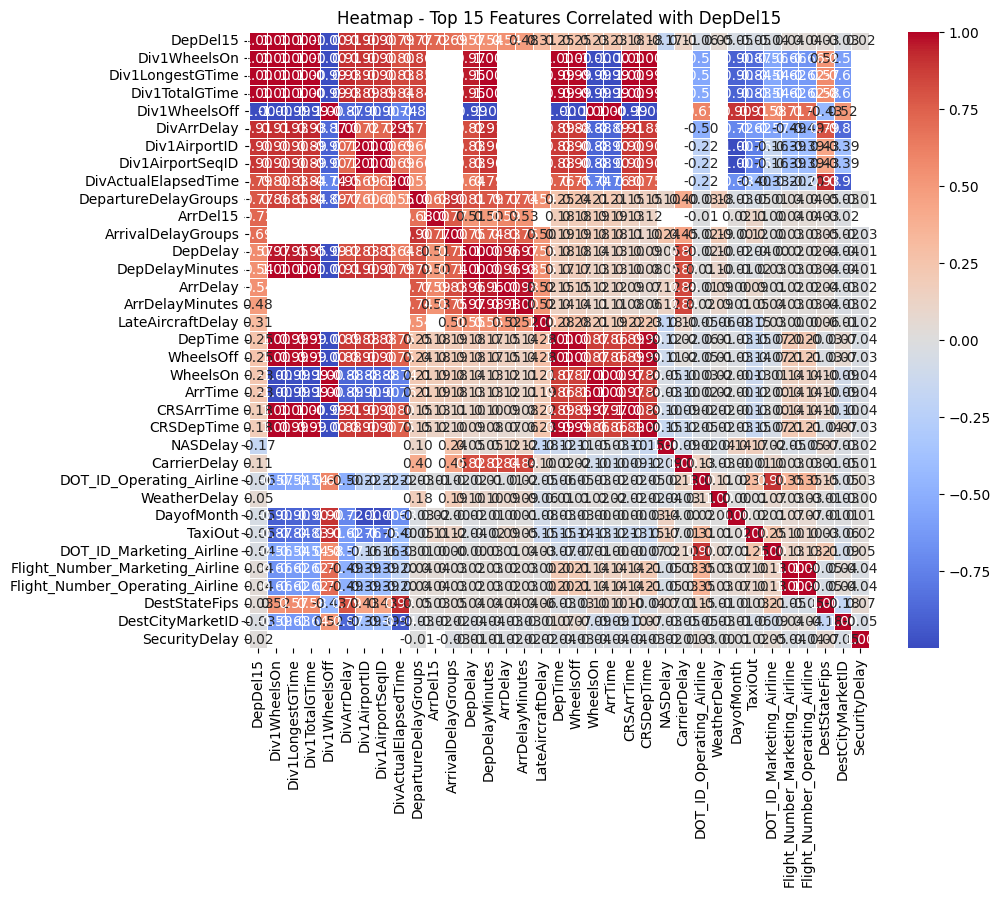

In [ ]:
X = df.drop(columns=['DepDel15'])
y = df['DepDel15']

# creare set temporar cu y inclus
temp_df = X.copy()
temp_df['DepDel15'] = y

# calculam matricea de corelatie doar cu variabile numerice
corr_matrix = temp_df.corr(numeric_only=True)

# extragem cele mai relevante 35 coloane corelate cu target-ul, in valoare absoluta
top_features = corr_matrix['DepDel15'].abs().sort_values(ascending=False).head(35).index

# filtram doar aceste coloane + randurile corespondente
filtered_corr = corr_matrix.loc[top_features, top_features]

# afisam heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap - Top 15 Features Correlated with DepDel15")
plt.show()


## Gestionarea valorilor lipsa

In [ ]:
null_values = df.isnull().sum()
null_values = null_values[null_values > 0] #afisam doar coloanele care au instante cu valori nule
print("Numar valori lipsa:")
print(null_values)

Numar valori lipsa:
ArrDelay                   4
ArrDelayMinutes            4
ArrDel15                   4
ArrivalDelayGroups         4
CancellationCode        3805
ActualElapsedTime          4
AirTime                    4
CarrierDelay            3209
WeatherDelay            3209
NASDelay                3209
SecurityDelay           3209
LateAircraftDelay       3209
FirstDepTime            3796
TotalAddGTime           3796
LongestAddGTime         3796
DivActualElapsedTime    3801
DivArrDelay             3801
Div1Airport             3801
Div1AirportID           3801
Div1AirportSeqID        3801
Div1WheelsOn            3801
Div1TotalGTime          3801
Div1LongestGTime        3801
Div1WheelsOff           3801
Div1TailNum             3801
dtype: int64


Observam ca avem 4 instante care nu au valoare pentru `ArrDel15` si dorim sa aflam daca aceste instante se pot corecta sau daca trebuie eliminate.

In [ ]:
print("Randuri cu valori lipsa:")
print(df[df['ArrDel15'].isnull()][['ArrDelay', 'ArrDelayMinutes', 'ArrDel15']])

Randuri cu valori lipsa:
        ArrDelay  ArrDelayMinutes  ArrDel15
16335        NaN              NaN       NaN
116116       NaN              NaN       NaN
313078       NaN              NaN       NaN
349848       NaN              NaN       NaN


Conform outputului de mai sus, putem elimina aceste intante, deoarece datele lor lipsesc.

In [ ]:
df = df[~df['ArrDel15'].isnull()]
print("Numar insante si variabile:", df.shape)

Numar insante si variabile: (3801, 67)


### Eliminam spatiile din capul de tabel

In [ ]:
#eliminam spatiile din captele numelor coloanelor
df.columns = df.columns.str.strip()

#verificare
print(df.columns)

Index(['DayofMonth', 'DayOfWeek', 'FlightDate', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline',
       'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline',
       'Operating_Airline', 'DOT_ID_Operating_Airline',
       'IATA_Code_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'DestAirportID', 'DestAirportSeqID',
       'DestCityMarketID', 'Dest', 'DestCityName', 'DestState',
       'DestStateFips', 'DestStateName', 'DestWac', 'CRSDepTime', 'DepTime',
       'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups',
       'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn',
       'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15',
       'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode',
       'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
       'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
  

### Imputare
Vom imputa cu 0 coloanele `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay` si `LateAircraftDelay`, deoarece lipsa valorilor inseamna lipsa intarzierii.

In [ ]:
cols_to_impute = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
for col in cols_to_impute:
    df.loc[:, col] = df[col].fillna(0) #:,col = toate liniile din coloana

Verificam coloanele cu multe valor nule, cat si Tail_Nuber, fiind un ID.

In [ ]:
relevant_cols = ['FirstDepTime',
                 'TotalAddGTime',
                 'LongestAddGTime',
                 'DivActualElapsedTime',
                 'DivArrDelay',
                 'Div1Airport',
                 'Div1AirportID',
                 'Div1AirportSeqID',
                 'Div1WheelsOn',
                 'Div1TotalGTime',
                 'Div1LongestGTime',
                 'Div1WheelsOff',
                 'Div1TailNum',
                 'CancellationCode']

for col in relevant_cols:
    print(f"\nAnalizăm: {col}") #afisam coloana analizata
    if df[col].dtype in ['float64', 'int64']:
        print(df.groupby('DepDel15')[col].mean()) #daca valoarea e numerica, se calculeaza media
    else:
        print(df.groupby('DepDel15')[col].value_counts(normalize=True)) #se afiseaza proportii



Analizăm: FirstDepTime
DepDel15
0.0            NaN
1.0    1250.666667
Name: FirstDepTime, dtype: float64

Analizăm: TotalAddGTime
DepDel15
0.0          NaN
1.0    24.222222
Name: TotalAddGTime, dtype: float64

Analizăm: LongestAddGTime
DepDel15
0.0          NaN
1.0    24.222222
Name: LongestAddGTime, dtype: float64

Analizăm: DivActualElapsedTime
DepDel15
0.0   NaN
1.0   NaN
Name: DivActualElapsedTime, dtype: float64

Analizăm: DivArrDelay
DepDel15
0.0   NaN
1.0   NaN
Name: DivArrDelay, dtype: float64

Analizăm: Div1Airport
Series([], Name: proportion, dtype: float64)

Analizăm: Div1AirportID
DepDel15
0.0   NaN
1.0   NaN
Name: Div1AirportID, dtype: float64

Analizăm: Div1AirportSeqID
DepDel15
0.0   NaN
1.0   NaN
Name: Div1AirportSeqID, dtype: float64

Analizăm: Div1WheelsOn
DepDel15
0.0   NaN
1.0   NaN
Name: Div1WheelsOn, dtype: float64

Analizăm: Div1TotalGTime
DepDel15
0.0   NaN
1.0   NaN
Name: Div1TotalGTime, dtype: float64

Analizăm: Div1LongestGTime
DepDel15
0.0   NaN
1.0   NaN
N

Observam ca aceste variabile sunt neinformative, cu exceptia FirstDepTime, TotalAddGTime si LongestAddGTime. Asadar, celelalte vor fi eliminate.

In [ ]:
#eliminam coloanele care nu au impact asupra variabilei dependente
cols_to_drop = [
    'DivActualElapsedTime',
    'DivArrDelay',
    'Div1Airport',
    'Div1AirportID',
    'Div1AirportSeqID',
    'Div1WheelsOn',
    'Div1WheelsOff',
    'Div1TotalGTime',
    'Div1LongestGTime',
    'Div1TailNum',
    'CancellationCode'
]
df = df.copy()
df.drop(columns=cols_to_drop, inplace=True)

Coloanele ramase (FirstDepTime, TotalAddGTime si LongestAddGTime) vor fi imputate cu 0 unde lipseste valoarea, fiind indici de timp.

In [ ]:
cols_to_fill_with_zero = ['FirstDepTime', 'TotalAddGTime', 'LongestAddGTime']

#imputare cu 0
for col in cols_to_fill_with_zero:
    df.loc[:, col] = df[col].fillna(0)

#verificare
print("Valori lipsa dupa imputare:")
print(df[cols_to_fill_with_zero].isnull().sum())


Valori lipsa dupa imputare:
FirstDepTime       0
TotalAddGTime      0
LongestAddGTime    0
dtype: int64


De asemenea, observam ca FlightDate este o variabila inutila, avand in vedere ca avem variabilele `DayOfMonth` and `DayOfWeek`, asa ca o vom elimina. Similar vom proceda si cu `Tail_Number`, acesta fiind doar un numar de identificare.

In [ ]:
col_to_drop = ['FlightDate', 'Tail_Number']
df = df.copy()
df.drop(columns=col_to_drop, inplace=True)

## Transformarea datelor

### Extragem trasaturile temporare

In [ ]:
#extragem ora programata de plecare din CRSDepTime
df['CRSDepHour'] = df['CRSDepTime'] // 100
df.loc[:, 'CRSDepHour'] = (df['CRSDepTime'] // 100).fillna(-1).astype(int) #completare cu -1 dacă lipsesc

#verificare
print(df[['DayOfWeek', 'CRSDepTime', 'CRSDepHour']].head())

      DayOfWeek  CRSDepTime  CRSDepHour
7725          2        1155          11
7726          2         725           7
7727          2        1800          18
7728          2        1440          14
7729          2         810           8


### Standardizare

Pasul urmator este sa aplicam standardizarea pentru coloanele numerice (`Distance`, `CRSElapsedTime`, `TaxiOut` si `AirTime`).

In [ ]:
cols_to_scale = ['Distance', 'CRSElapsedTime', 'TaxiOut', 'AirTime']

#initializam scalerul si standardizam valorile
scaler = StandardScaler() #standard scaler seteaza media la 0 si deviatia standard la 1
df.loc[:, cols_to_scale] = scaler.fit_transform(df[cols_to_scale]) #calculeaza media si deviatia standard, apoi transforma datele

#verificare
print(df[cols_to_scale].describe())

           Distance  CRSElapsedTime       TaxiOut      AirTime
count  3.801000e+03    3.801000e+03  3.801000e+03  3801.000000
mean  -2.990972e-17    1.495486e-17 -1.495486e-17     0.000000
std    1.000132e+00    1.000132e+00  1.000132e+00     1.000132
min   -9.344307e-01   -9.746641e-01 -1.363157e+00    -0.974291
25%   -6.687907e-01   -6.883062e-01 -6.223808e-01    -0.648643
50%   -5.394205e-01   -4.735378e-01 -2.519926e-01    -0.436264
75%   -5.816358e-02    2.423570e-01  3.035897e-01     0.229190
max    2.994972e+00    3.377976e+00  1.252640e+01     3.797156


Similar, vom aplica codificarea pentru toae coloanele de tip obiect ramase.

In [ ]:
#codificam variabilele de tip object
for col in df.select_dtypes(include=['object']).columns:
    print(f"Codificam: {col}")
    le = LabelEncoder()
    df.loc[:, col] = le.fit_transform(df[col].astype(str))  #asigneaza valori numerice pentru fiecare valoare string

Codificam: Marketing_Airline_Network
Codificam: Operated_or_Branded_Code_Share_Partners
Codificam: IATA_Code_Marketing_Airline
Codificam: Operating_Airline
Codificam: IATA_Code_Operating_Airline
Codificam: Dest
Codificam: DestCityName
Codificam: DestState
Codificam: DestStateName
Codificam: DepTimeBlk
Codificam: ArrTimeBlk


### Labeling
Mai departe, dorim sa verificam tipurile de date pentru consistenta.

In [ ]:
#afisam tipurile de date
print("Tipuri de date:")
print(df.dtypes.value_counts())

#afisare detaliata pentru fiecare coloana
print("\nTipuri de date pe coloane:")
print(df.dtypes)

Tipuri de date:
float64    28
int64      16
object     11
Name: count, dtype: int64

Tipuri de date pe coloane:
DayofMonth                                   int64
DayOfWeek                                    int64
Marketing_Airline_Network                   object
Operated_or_Branded_Code_Share_Partners     object
DOT_ID_Marketing_Airline                     int64
IATA_Code_Marketing_Airline                 object
Flight_Number_Marketing_Airline              int64
Operating_Airline                           object
DOT_ID_Operating_Airline                     int64
IATA_Code_Operating_Airline                 object
Flight_Number_Operating_Airline              int64
DestAirportID                                int64
DestAirportSeqID                             int64
DestCityMarketID                             int64
Dest                                        object
DestCityName                                object
DestState                                   object
DestStateFips        

In [ ]:
#afisam coloanele de tip object
object_cols = df.select_dtypes(include=['object']).columns
print("Coloane de tip obiect:")
print(object_cols)

Coloane de tip obiect:
Index(['Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'IATA_Code_Marketing_Airline', 'Operating_Airline',
       'IATA_Code_Operating_Airline', 'Dest', 'DestCityName', 'DestState',
       'DestStateName', 'DepTimeBlk', 'ArrTimeBlk'],
      dtype='object')


Astfel, vom codifica toate coloanele returnate.

In [ ]:
#coloanele care vor fi codificate
label_cols=[
    'Marketing_Airline_Network',
    'Dest',
    'DepTimeBlk',
    'ArrTimeBlk'
]

#codificam coloanele si afisam valorile
for col in label_cols:
  print(col, ":", df[col].nunique(), "valori unice")
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col].astype(str))  #convertim la string pentru a nu aparea erori nu NaN

Marketing_Airline_Network : 7 valori unice
Dest : 32 valori unice
DepTimeBlk : 19 valori unice
ArrTimeBlk : 18 valori unice


## Curatarea datelor

### Detectarea si eliminarea outlierilor
Folosind metoda IQR (Interquartile Range), vom detecta si elimina outlierii.

In [ ]:
#selectam doar coloanele numerice
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

#initializam un dictionar pentru a stoca outlierii
outliers_dict = {}

#iteram prin fiecare coloana numerica si calculam outlierii
for col in numeric_cols:
  Q1 = df[col].quantile(0.25) #primul quartil (25%)
  Q3 = df[col].quantile(0.75) #al treilea quartil (75%)
  IQR = Q3 - Q1 #intervalul quartil
  lower_bound = Q1 - 1.5 * IQR #pragul inferior pentru outlieri
  upper_bound = Q3 + 1.5 * IQR #pragul superior pentru outlieri
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)] #selectam outlierii
  if not outliers.empty: #verificam daca exista outlieri
      outliers_dict[col] = len(outliers) #stocam numarul de outlieri pentru acea coloana

# afisam numarul de outlieri identificati per coloana
print("Numar de outlieri identificati per coloana:")
for col, count in outliers_dict.items():
  print(f"{col}: {count}")

Numar de outlieri identificati per coloana:
DOT_ID_Marketing_Airline: 92
DestWac: 373
DepDelay: 506
DepDelayMinutes: 712
DepDel15: 604
DepartureDelayGroups: 357
TaxiOut: 229
WheelsOn: 10
TaxiIn: 264
CRSArrTime: 6
ArrTime: 12
ArrDelay: 317
ArrDelayMinutes: 718
ArrDel15: 596
ArrivalDelayGroups: 340
CRSElapsedTime: 336
ActualElapsedTime: 322
AirTime: 336
Distance: 693
DistanceGroup: 693
CarrierDelay: 297
WeatherDelay: 11
NASDelay: 239
SecurityDelay: 1
LateAircraftDelay: 317
FirstDepTime: 9
TotalAddGTime: 9
LongestAddGTime: 9


Observam ca avem multi outlieri in coloane importante, insa nu le putem elimina, avand in vedere ca acestea sunt plauzibile (ex: timp de intarziere foarte mare).

Asadar, urmatorul pas este sa realizam o distributie a outlierilor pentru fiecare coloana numerica, pentru a vedea daca outlierii apar mai frecvent in randurile une `DepDel15 == 1` decat in cele unde `DepDel15 == 0`. Daca da, atunci outlierii sunt relevanti, iar daca nu, pot fi eliminati, fiind zgomot.

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25) #primul quartil
    Q3 = df[col].quantile(0.75) #al treila quartil
    IQR = Q3 - Q1 #IQR - masura a dispersiei
    lower = Q1 - 1.5 * IQR #limita inferioara
    upper = Q3 + 1.5 * IQR #limita superioara

    outliers = df[(df[col] < lower) | (df[col] > upper)] #selectam outlierii
    total_outliers = len(outliers) #calculam cati outlieri sunt

    if total_outliers > 0:
        pct_delayed = outliers['DepDel15'].mean() * 100 #calculam procentul de outlieri cand sunt intarziati
        print(f"{col}: {total_outliers} outlieri, {pct_delayed:.2f}% din ei sunt intarziati (DepDel15=1)")


DOT_ID_Marketing_Airline: 92 outlieri, 21.74% din ei sunt intarziati (DepDel15=1)
DestWac: 373 outlieri, 12.87% din ei sunt intarziati (DepDel15=1)
DepDelay: 506 outlieri, 100.00% din ei sunt intarziati (DepDel15=1)
DepDelayMinutes: 712 outlieri, 84.83% din ei sunt intarziati (DepDel15=1)
DepDel15: 604 outlieri, 100.00% din ei sunt intarziati (DepDel15=1)
DepartureDelayGroups: 357 outlieri, 100.00% din ei sunt intarziati (DepDel15=1)
TaxiOut: 229 outlieri, 9.61% din ei sunt intarziati (DepDel15=1)
WheelsOn: 10 outlieri, 50.00% din ei sunt intarziati (DepDel15=1)
TaxiIn: 264 outlieri, 12.88% din ei sunt intarziati (DepDel15=1)
CRSArrTime: 6 outlieri, 33.33% din ei sunt intarziati (DepDel15=1)
ArrTime: 12 outlieri, 58.33% din ei sunt intarziati (DepDel15=1)
ArrDelay: 317 outlieri, 92.43% din ei sunt intarziati (DepDel15=1)
ArrDelayMinutes: 718 outlieri, 71.17% din ei sunt intarziati (DepDel15=1)
ArrDel15: 596 outlieri, 77.01% din ei sunt intarziati (DepDel15=1)
ArrivalDelayGroups: 340 ou

Conform acestor rezultate, verificam: `DOT_ID_Marketing_Airline`, `DestWac`, `TaxiOut`, `TaxiIn`, `CRSElapsedTime`, `ActualElapsedTime`, `AirTime`, `Distance` si
`DistanceGroup`.

In [ ]:
irrelevant_outlier_cols = [
    'DOT_ID_Marketing_Airline', 'DestWac', 'TaxiOut', 'TaxiIn',
    'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
    'Distance', 'DistanceGroup'
]

#calculam zscore pentru coloanele respective
z_scores = df[irrelevant_outlier_cols].apply(zscore)

#pastram in masca doar instantele cu zscore < 3
mask = (z_scores.abs() < 3).all(axis=1)

#afisam cate randuri vor fi eliminate
print("Randuri eliminate (outlieri irelevanti):", (~mask).sum())

#eliminam outlierii
df = df[mask]

#verificam dimensiunea noului set de date
print("Dimensiunea setului de date după eliminare:", df.shape)


Randuri eliminate (outlieri irelevanti): 417
Dimensiunea setului de date după eliminare: (3384, 55)


### Stergerea variabilelor echivalente cu DepDel15

In [ ]:
X_numeric = df.drop(columns=['DepDel15'])
y = df['DepDel15']

#calculam mutual information (discrete_features -> ne spune daca feature-ul este continuu sau categorie)
mi_scores = mutual_info_classif(X_numeric, y, discrete_features='auto', random_state=42)

#sortam
mi_series = pd.Series(mi_scores, index=X_numeric.columns).sort_values(ascending=False)

print("Coloane cu cel mai mare mutual information față de DepDel15:\n")
print(mi_series.head(20))


Coloane cu cel mai mare mutual information față de DepDel15:

DepartureDelayGroups               0.439259
DepDelay                           0.439111
DepDelayMinutes                    0.439111
ArrDelayMinutes                    0.317595
ArrDelay                           0.314986
ArrivalDelayGroups                 0.298227
ArrDel15                           0.233011
LateAircraftDelay                  0.157059
CarrierDelay                       0.114773
DepTime                            0.059657
WheelsOff                          0.056764
ArrTime                            0.043614
NASDelay                           0.039533
WheelsOn                           0.038559
CRSArrTime                         0.033918
DayofMonth                         0.025454
Flight_Number_Marketing_Airline    0.025025
Flight_Number_Operating_Airline    0.024442
CRSDepTime                         0.024435
CRSDepHour                         0.019667
dtype: float64


Dupa cum putem observa, `DepartureDelayGroups`, `DepDelay`, `DepDelayMinutes`, `ArrDelay`, `ArrDelayMinutes`, `ArrivalDelayGroups` si `ArrDel15`, `LateAircraftDelay`, `CarrierDelay`, `DepTime`, `WheelsOff` sunt direct dependente de intarzierea reala, deci aceste variabile trebuie eliminate.

In [ ]:
cols_to_drop = [
    'DepartureDelayGroups',
    'DepDelay',
    'DepDelayMinutes',
    'ArrDelayMinutes',
    'ArrDelay',
    'ArrivalDelayGroups',
    'ArrDel15',
    'LateAircraftDelay',
    'CarrierDelay',
    'DepTime',
    'WheelsOff'
]

df.drop(columns=cols_to_drop, inplace=True)

Deoarece variabilele `Carrier`, `Origin`, `Dest` si `DayOfWeek` sunt de tip nominal, este important sa le transformam in variabile categorice codificate corespunzator. Pentru a evita ca algoritmii sa interpreteze valorile numerice ca avand o relatie ordonata, aplicat one-hot encoding, folosing `pd.get_dummies()`.

In [ ]:
# Identifică coloanele categorice automat
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) #one-hot encoding

# Impartirea setului de date

In [ ]:
#separam variabila tinta de atributele predictive
X = df.drop(columns=['DepDel15']) #atributele
y = df['DepDel15'] #variabila tinta

#impartim datele in set de antrenament(80%) si set de test (20%)
#stratify ne da 20% de test din fiecare clasa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#verificare
print("Dimensiunea setului de antrenament:", X_train.shape)
print("Dimensiunea setului de test:", X_test.shape)
print("Dimensiunea variabilei tinta de antrenament:", y_train.shape)
print("Dimensiunea variabilei tinta de test:", y_test.shape)

Dimensiunea setului de antrenament: (2707, 112)
Dimensiunea setului de test: (677, 112)
Dimensiunea variabilei tinta de antrenament: (2707,)
Dimensiunea variabilei tinta de test: (677,)


Pie chart cu impartirea setului de date

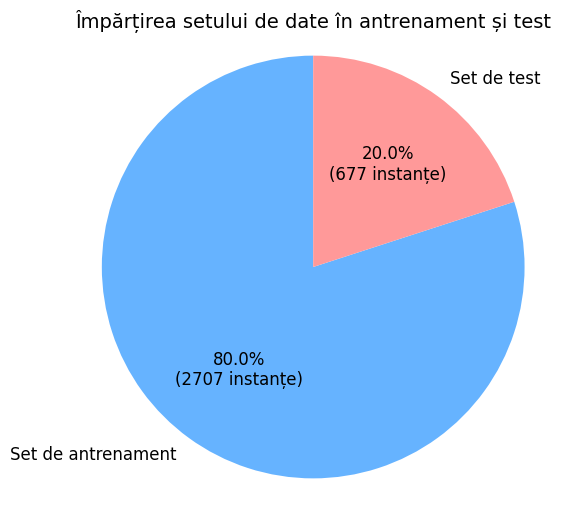

In [ ]:
#dimeniuni calculate automat
train_size = len(X_train)
test_size = len(X_test)

sizes = [train_size, test_size]
labels = ['Set de antrenament', 'Set de test']
colors = ['#66b3ff', '#ff9999']

#functie care formateaza procentajul si adauga numarul de instante
def make_autopct(sizes):
    def my_autopct(pct):
        total = sum(sizes)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count} instanțe)'
    return my_autopct

#creare grafic
plt.figure(figsize=(6, 6))
plt.pie(sizes,
        labels=labels,
        colors=colors,
        autopct=make_autopct(sizes),
        startangle=90,
        textprops={'fontsize': 12})
plt.title('Împărțirea setului de date în antrenament și test', fontsize=14)
plt.axis('equal')
plt.show()


# Selectarea metricilor de perormanta urmarite si metoda de validare a rezultatelor

## Metrici de performanta

Metricile de performanta alese sunt:
- `accuracy`: proportia de predictii corecte
- `precision`: cat de corecte sunt predictiile pozitive
- `recall`: proporti cazurilor pozitive identificate corect
- `f1-score`: media armonica intre precizie si recall
- `AUC-ROC`: cat de bine distinge modelul intre cele doua clase

De asemenea, vom folosi si `matricea de confuzie`.

## Metoda de validare

Metoda de validare folosita va fi Cross-validation (k-fold). Impartind setul de antrenament in k (noi vom alege k = 5) subgrupuri, il vom valida pe 1 set, repetand procesul de k ori. Fiecare subsete este utilizat o data pentru validare.

# Selectarea metodelor de predictie

Avand in vedere natura problmei (clasificare binara), am ales sa folosim urmatoarele metode de predictie, pentru a putea realiza o comparatie riguroasa:
- Regrestie Logistica
  - metoda de baza pentru clasificarea binara, folosit adesea ca punct de referinta in comparatiile intre modele
  - permite interpretarea coeficientilor si a influentei variabielelor asupra variabilei dependente
- Random Forest
  - algoritm ensemble bazat pe arbori de decizie
  - ofera performante ridicate si robustete la outlieri
- Gradient Boosting
  - spre deosebire de random forest, boostingpul construieste arborii in mod secvential, corectand greselile modelului anterior
- XGBoost
  - ofera acuratete ridicata
  - gestioneaza eficient zgomotul
  - include mecanisme care reduc suprainvaatarea

# Aplicarea metodelor stabilite

## Regresie logistica

Parametri aleși pentru Regresia Logistică sunt `C`, `penalty=l2` și `solver=liblinear`. `C` controlează regularizarea, pentru a preveni overfitting, `penalty=l2` este standardul pentru regresia logistică regularizată și ajută la stabilitatea modelului, evitând coeficienții extremi, iar `solver=liblinear` a fost ales din motive de performanță.

Best Logistic Regression Parameters (cv=5): {'C': 0.01, 'penalty': 'l2'}

Evaluare pe setul de validare:
Accuracy: 0.9016
Precision: 1.0000
Recall (Sensitivity): 0.3846
Specificity: 1.0000
F1-score: 0.5556
AUC: 0.9211
Confusion Matrix:
 [[683   0]
 [ 80  50]]


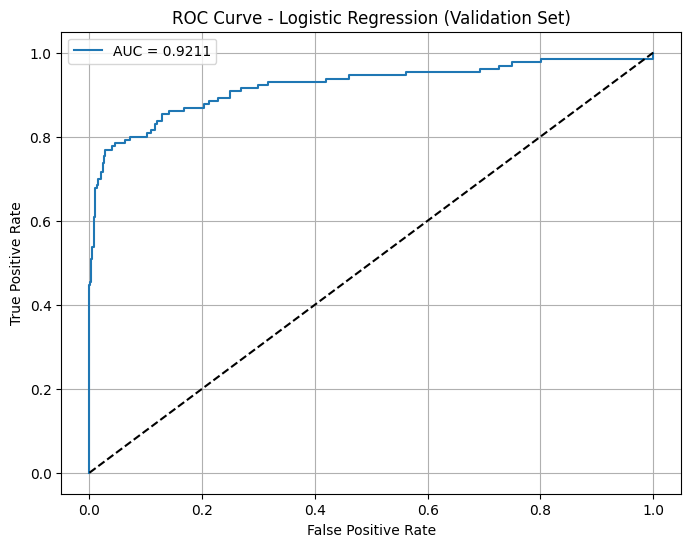

In [ ]:
#impartire interna a setului de antrenament in 70% antrenament si 30% validare
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

#definirea modelului si grilei de hiperparametri
log_reg = LogisticRegression(max_iter=5000, solver='liblinear')
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}

#cross-vaidation pe 70% din setul de antrenament
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_sub, y_train_sub)

#cel mai bun model si parametri
best_log_reg = grid_search.best_estimator_
print("Best Logistic Regression Parameters (cv=5):", grid_search.best_params_)

#predictii pe setul de validare (30% din cele 80%)
y_val_pred = best_log_reg.predict(X_val) #predict: label clase (0 sau 1)
y_val_prob = best_log_reg.predict_proba(X_val)[:, 1] #predict proba: probabilitatea folosita pentru ROC

#matricea de confuzie
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

#metrici
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_prob)

print("\nEvaluare pe setul de validare:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)

#curba ROC
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob) #false positive rate, true positive rate
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Validation Set)")
plt.legend()
plt.grid()
plt.show()

#variabile pentru curbele ROC pe acelasi grafic
fpr_lr = fpr
tpr_lr = tpr
auc_lr = auc
acc_lr = accuracy
prec_lr = precision
recall_lr = recall
f1_lr = f1
spec_lr = specificity

## Random forest

În cazul Random Forest, am ales `n_estimators`, `max_depth` și `max_features`.

 `N_estimators` reprezintă numărul de arbori. Cu cât mai mulți arbori, cu atât mai bună performanța, însă acest lucru vine și cu un cost computațional mai mare.

 `Max_depth` reprezintă adâncimea maximă a fiecărui arbore, prevenind overfittingul, iar `max_features` reprezintă numărul de vairbile candidate la fiecare split.
`Sqrt` și `log2` sunt variabile standard pentru clasificare, reducând corelația dintre arbori și reducând diversitatea în forest.
Acești parametri au fost aleși pentru a combate bias-ul și varianța, evitând atât overfitting, cât și underfitting.


Best Random Forest Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}

Evaluare pe setul de validare:
Accuracy: 0.8745
Precision: 0.8889
Recall (Sensitivity): 0.2462
Specificity: 0.9941
F1-score: 0.3855
AUC: 0.8731
Confusion Matrix:
 [[679   4]
 [ 98  32]]


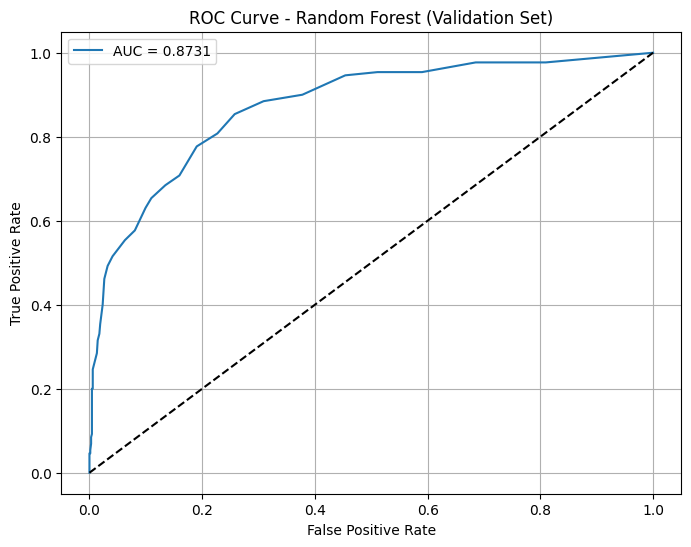

In [ ]:
#impartire interna a setului de antrenament in 70% train si 30% validare
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

#definirea modelului
rf = RandomForestClassifier(
    random_state=42,
    oob_score=True,  #folosit pentru validare interna
    bootstrap=True
)

#grila de hiperparametri
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

#cross validation pe 70% din setul de antrenament
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_sub, y_train_sub)

#cel mai bun model si parametri
best_rf = grid_search.best_estimator_
print("Best Random Forest Parameters:", grid_search.best_params_)

#predictii pe setul de validare (30% din cele 80%)
y_val_pred = best_rf.predict(X_val)
y_val_prob = best_rf.predict_proba(X_val)[:, 1]

#matrice de confuzie
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

#metrici
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_prob)

print("\nEvaluare pe setul de validare:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)

#curba ROC
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Validation Set)")
plt.legend()
plt.grid()
plt.show()

#variabile pentru curbele ROC pe acelasi grafic
fpr_rf = fpr
tpr_rf = tpr
auc_rf = auc
acc_rf = accuracy
prec_rf = precision
recall_rf = recall
f1_rf = f1
spec_rf = specificity

## Gradient Boosting

La GradientBoosting am ales `n_estimators`, care reprezintă numărul total de arbori. `Learning_rate` ne arată cât de mult contribuie fiecare arbore, fapt ce ajută la stabilitate și generalizare, iar `max_depth` reprezintă adâncimea arborilor. Arborii sunt adesea shallow, însă combinați inteligent.

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Evaluare pe setul de validare (Gradient Boosting):
Accuracy: 0.9287
Precision: 0.9390
Recall (Sensitivity): 0.5923
Specificity: 0.9927
F1-score: 0.7264
AUC: 0.9371
Confusion Matrix:
 [[678   5]
 [ 53  77]]


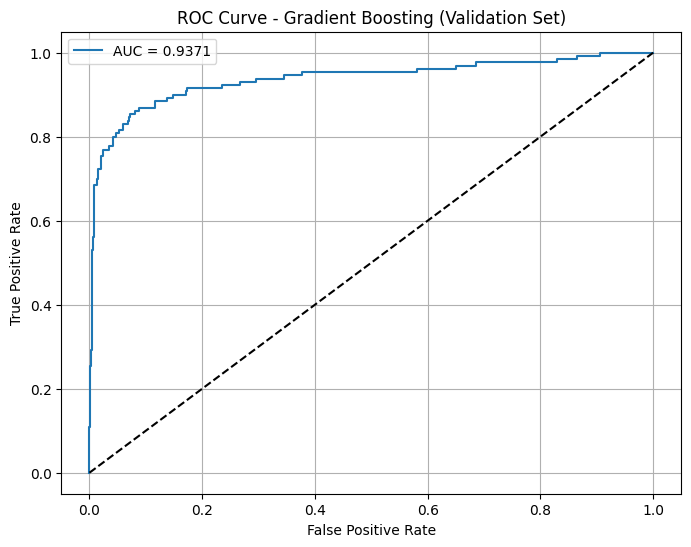

In [ ]:
#impartire interna a setului de antrenament in 70% train si 30% validare
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

#definire model si hiperparametri
gb = GradientBoostingClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200], #~1000
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

#cross validation pe 70% din setul de antrenament
grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_sub, y_train_sub)

#cel mai bun model si parametri
best_gb = grid_search.best_estimator_
print("Best Gradient Boosting Parameters:", grid_search.best_params_)

#predictii pe setul de validare (30% din cele 80%)
y_val_pred = best_gb.predict(X_val)
y_val_prob = best_gb.predict_proba(X_val)[:, 1]

#matrice de confuzie si metrici
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_prob)

print("\nEvaluare pe setul de validare (Gradient Boosting):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)

#curba ROC
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting (Validation Set)")
plt.legend()
plt.grid()
plt.show()

#variabile pentru curbele ROC pe acelasi grafic
fpr_gb = fpr
tpr_gb = tpr
auc_gb = auc
acc_gb = accuracy
prec_gb = precision
recall_gb = recall
f1_gb = f1
spec_gb = specificity

## XGBoost

În cele din urmă, pentru XGBoost am ales parametri `n_estimators`, care indică numărul de arbori boosting, `max_depth` și `learning_rate`, care, la fel ca la GB, controlează cât de rapid și cât de bine învață modelul, `subsample=0.8` ajută la regularizare, reducând overfittingul, iar eval_metric=logloss este folosit pentru clasificare binară.

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

Evaluare pe setul de validare (XGBoost):
Accuracy: 0.9053
Precision: 0.9344
Recall (Sensitivity): 0.4385
Specificity: 0.9941
F1-score: 0.5969
AUC: 0.9185
Confusion Matrix:
 [[679   4]
 [ 73  57]]


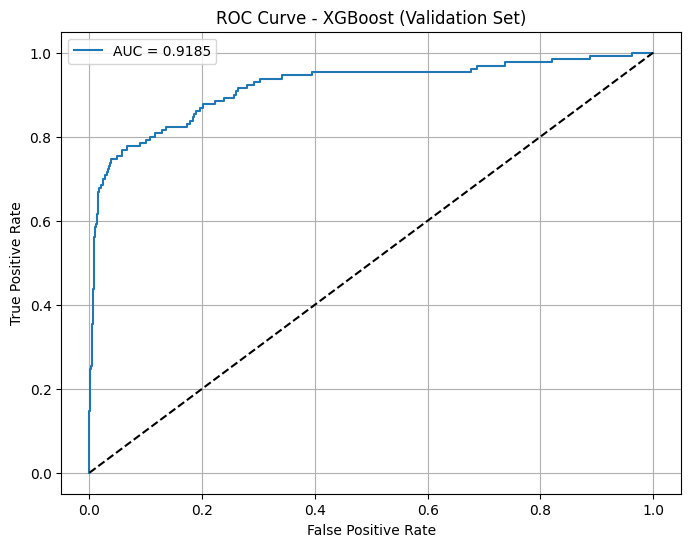

In [ ]:
#impartire interna a setului de antrenament in 70% train si 30% validare
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

#definire model si hiperparametri
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8]
}

#cross validation pe 70% din setul de antrenament
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_sub, y_train_sub)

#cel mai bun model si parametri
best_xgb = grid_search.best_estimator_
print("Best XGBoost Parameters:", grid_search.best_params_)

#predictii pe setul de validare (30% din cele 80%)
y_val_pred = best_xgb.predict(X_val)
y_val_prob = best_xgb.predict_proba(X_val)[:, 1]

#matrice de confuzie
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_prob)

#metrici
print("\nEvaluare pe setul de validare (XGBoost):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)

#curba ROC
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (Validation Set)")
plt.legend()
plt.grid()
plt.show()

#variabile pentru curbele ROC pe acelasi grafic
fpr_xg = fpr
tpr_xg = tpr
auc_xg = auc
acc_xg = accuracy
prec_xg = precision
recall_xg = recall
f1_xg = f1
spec_xg = specificity

# Performantele in comparatie

## Curbele ROC

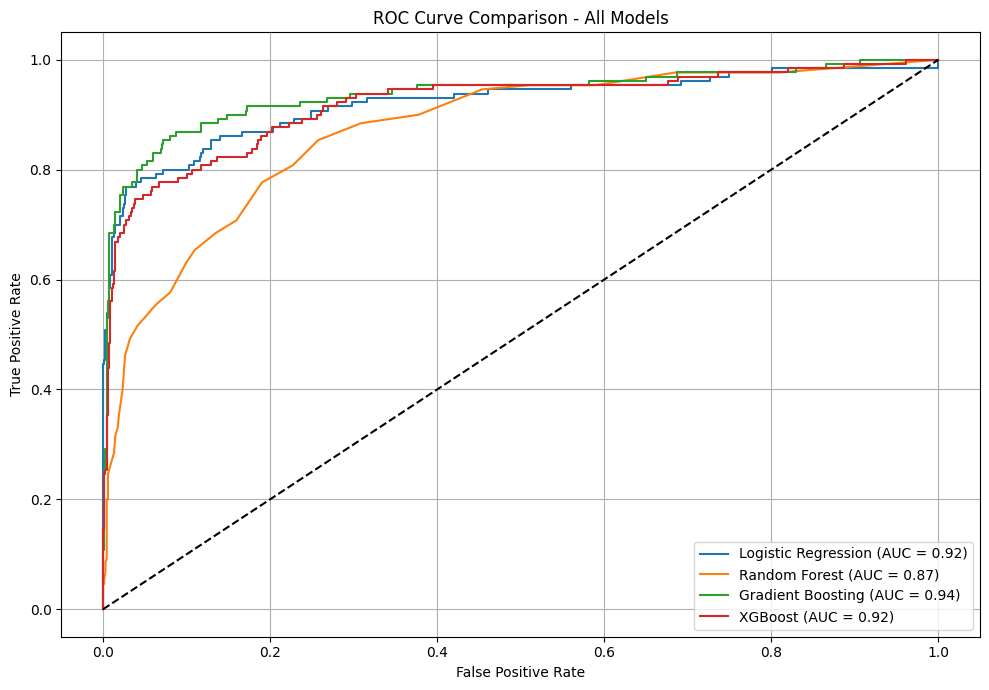

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.2f})')
plt.plot(fpr_xg, tpr_xg, label=f'XGBoost (AUC = {auc_xg:.2f})')

#linie de referinta
plt.plot([0, 1], [0, 1], 'k--') #black dashed line

#labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


## Metricile

In [ ]:
#tabel care pune toate matricile impreuna, de la toate modelele
results = {
    'Model': ['Logistic Reg.', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'AUC': [auc_lr, auc_rf, auc_gb, auc_xg],
    'Recall (Sens.)': [recall_lr, recall_rf, recall_gb, recall_xg],
    'F1-score': [f1_lr, f1_rf, f1_gb, f1_xg],
    'Accuracy': [acc_lr, acc_rf, acc_gb, acc_xg],
    'Precision': [prec_lr, prec_rf, prec_gb, prec_xg],
    'Specificity': [spec_lr, spec_rf, spec_gb, spec_xg]
}

df_results = pd.DataFrame(results)
display(df_results)

,Model,AUC,Recall (Sens.),F1-score,Accuracy,Precision,Specificity
0,Logistic Reg.,0.921140,0.384615,0.555556,0.901599,1.000000,1.000000
1,Random Forest,0.873128,0.246154,0.385542,0.874539,0.888889,0.994143
2,Gradient Boosting,0.937076,0.592308,0.726415,0.928659,0.939024,0.992679
3,XGBoost,0.918527,0.438462,0.596859,0.905289,0.934426,0.994143


## Grafice pentru metrici

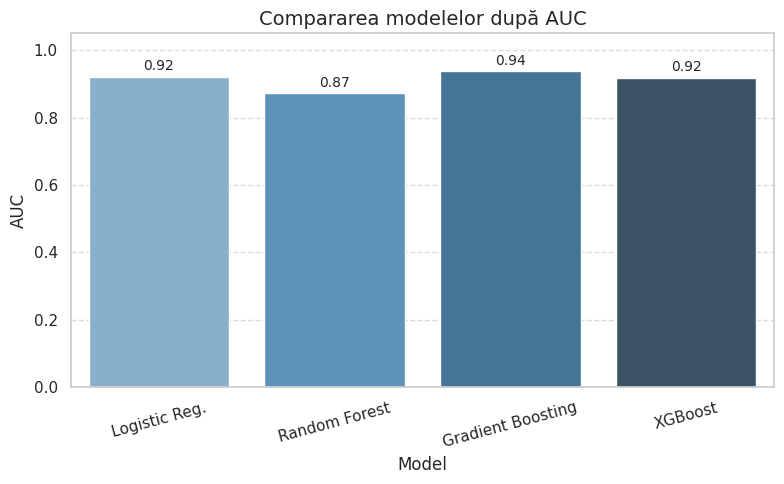

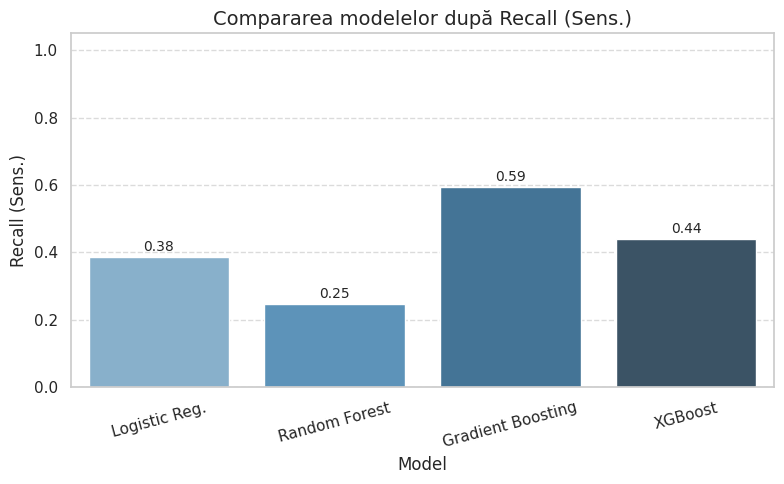

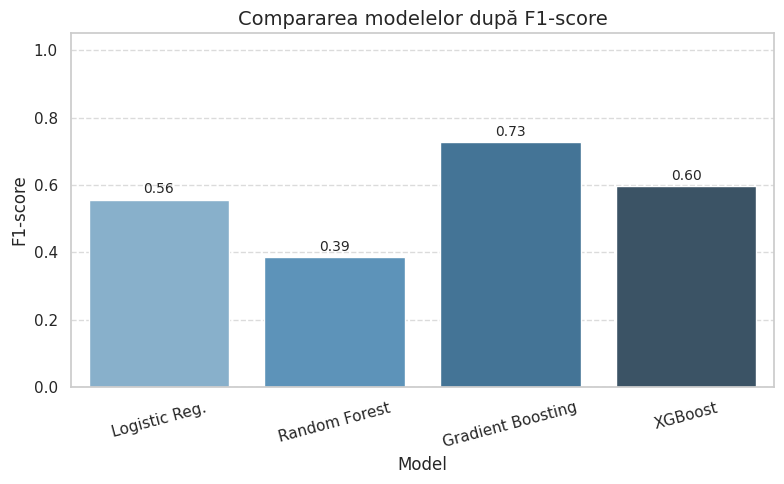

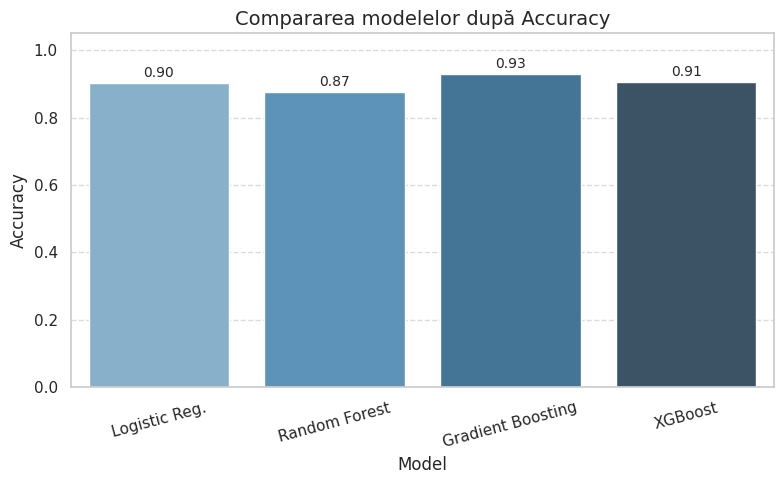

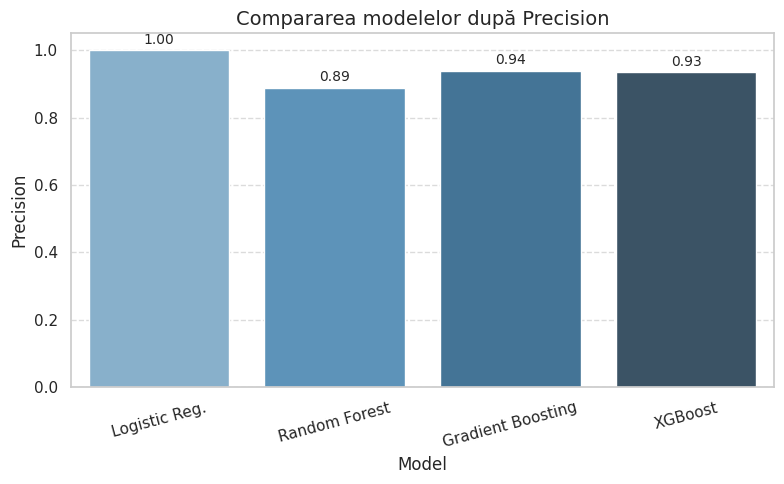

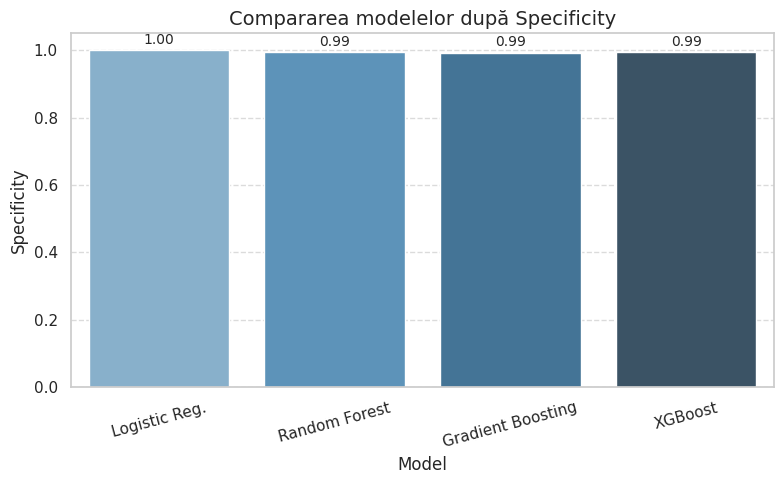

In [ ]:
sns.set(style="whitegrid")

#metrici
metrics = ['AUC', 'Recall (Sens.)', 'F1-score', 'Accuracy', 'Precision', 'Specificity']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='Model', y=metric, hue='Model', data=df_results, palette='Blues_d', legend=False)

    #adaugare valoare pe bars
    for i, val in enumerate(df_results[metric]):
        plt.text(i, val + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=10)

    plt.title(f'Compararea modelelor după {metric}', fontsize=14)
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.xlabel('Model')
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.7) #alpha seteaza transparenta
    plt.tight_layout()
    plt.show()

## Interpretare

Observam ca dintre toate modelele, `Gradient Boosting` este cel mei performant si echilibrat model.
Acesta are cel mai bun recall, care este esential pentru detectarea clasei pozitive, cel mai mare AUC, cea mai mare acuratete si f1-score si specificitate buna, fara overfitting. <br/>

`XGBoost` are scoruri apropiate, insa are recall mai slab, chiar daca are precision mare.

`Random Forest` ofera rezultate solide, in special printr-o specificitate foarte ridicata si o precizie buna, insa este afectat de un recall i un f1-score mai redus.

`Regresia logistica` se dovesteste a fi cea mai slaba dintre aceste 4 modele. Avand precision de 1.000, a prezis foarte putine pozitive, insa cele prezise au fost corecte. Aceasta nu face overiftting, insa are bias ridicat.

# Crearea modelului final

In [ ]:
#parametrii cei mai buni din grid search
best_params = {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

#antrenare finala pe intregul set de antrenament
final_gb_model = GradientBoostingClassifier(
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    n_estimators=best_params['n_estimators'],
    random_state=42
)

final_gb_model.fit(X_train, y_train)


GradientBoostingClassifier(max_depth=5, n_estimators=200, random_state=42)

##Aplicarea modelului final pe setul de testare


Evaluare finală pe setul de testare (Gradient Boosting):
Accuracy: 0.9099
Precision: 0.8133
Recall (Sensitivity): 0.5648
Specificity: 0.9754
F1-score: 0.6667
AUC: 0.9104
Confusion Matrix:
 [[555  14]
 [ 47  61]]


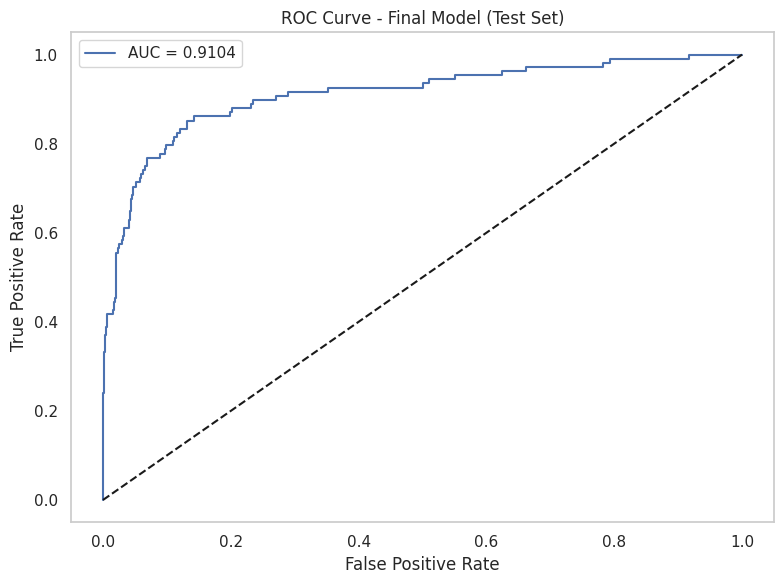

In [ ]:
#predictii pe setul de testare (20%)
y_test_pred = final_gb_model.predict(X_test)
y_test_prob = final_gb_model.predict_proba(X_test)[:, 1]

#matrice de confuzie
cm_test = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm_test.ravel()

#metrici finale
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
specificity_test = tn / (tn + fp)
f1_test = f1_score(y_test, y_test_pred)
auc_test = roc_auc_score(y_test, y_test_prob)

print("\nEvaluare finală pe setul de testare (Gradient Boosting):")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall (Sensitivity): {recall_test:.4f}")
print(f"Specificity: {specificity_test:.4f}")
print(f"F1-score: {f1_test:.4f}")
print(f"AUC: {auc_test:.4f}")
print("Confusion Matrix:\n", cm_test)

#curba ROC pe test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label=f"AUC = {auc_test:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model (Test Set)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Grafic pentru metrici

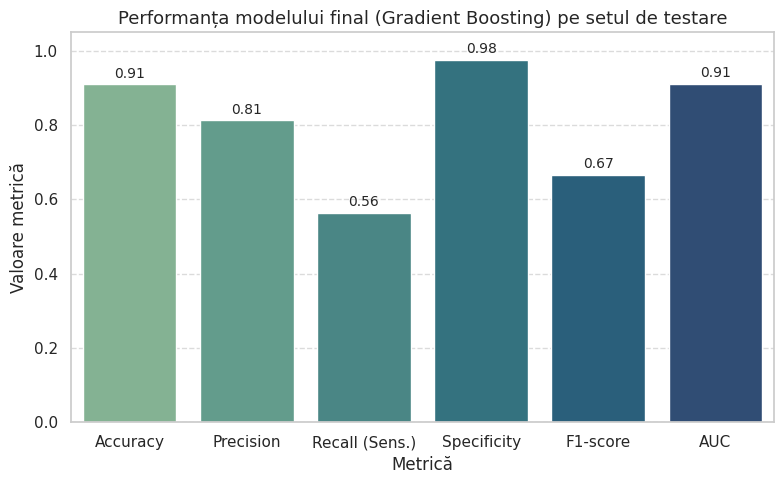

In [ ]:
#dictionar cu toate metricile modelului final
final_metrics = {
    'Accuracy': accuracy_test,
    'Precision': precision_test,
    'Recall (Sens.)': recall_test,
    'Specificity': specificity_test,
    'F1-score': f1_test,
    'AUC': auc_test
}

#transformare in dataframe pentru vizualizare
final_df = pd.DataFrame(list(final_metrics.items()), columns=['Metrică', 'Valoare'])

#plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Metrică', y='Valoare', hue='Metrică', data=final_df, palette='crest', legend=False)

#valori pe bare
for i, val in enumerate(final_df['Valoare']):
    plt.text(i, val + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.ylim(0, 1.05)
plt.title('Performanța modelului final (Gradient Boosting) pe setul de testare', fontsize=13)
plt.ylabel('Valoare metrică')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
